In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [10]:
train_df = pd.read_csv('agricultural_yield_train.csv')
test_df  = pd.read_csv('agricultural_yield_test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (16000, 7)
Test shape:  (4000, 7)


,Soil_Quality,Seed_Variety,Fertilizer_Amount_kg_per_hectare,Sunny_Days,Rainfall_mm,Irrigation_Schedule,Yield_kg_per_hectare
0,96.415657,1,147.853040,94.593926,444.267569,3,683.759119
1,92.352626,0,281.565396,90.504644,517.585491,7,678.714861
2,63.714785,1,137.864940,97.329340,420.310945,8,934.691975
3,90.084256,1,100.946659,113.404828,547.817646,7,905.842541
4,81.600341,1,223.088908,83.048176,434.726333,6,897.584665


In [11]:
print('Data Types:\n', train_df.dtypes)
print('\nMissing Values:\n', train_df.isnull().sum())
print('\nBasic Statistics:')
train_df.describe()

Data Types:
 Soil_Quality                        float64
Seed_Variety                          int64
Fertilizer_Amount_kg_per_hectare    float64
Sunny_Days                          float64
Rainfall_mm                         float64
Irrigation_Schedule                   int64
Yield_kg_per_hectare                float64
dtype: object

Missing Values:
 Soil_Quality                        0
Seed_Variety                        0
Fertilizer_Amount_kg_per_hectare    0
Sunny_Days                          0
Rainfall_mm                         0
Irrigation_Schedule                 0
Yield_kg_per_hectare                0
dtype: int64

Basic Statistics:


,Soil_Quality,Seed_Variety,Fertilizer_Amount_kg_per_hectare,Sunny_Days,Rainfall_mm,Irrigation_Schedule,Yield_kg_per_hectare
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,74.759340,0.702000,175.179275,99.927792,500.527248,5.033313,713.999725
std,14.529295,0.457394,71.971900,9.980610,100.062422,2.229689,202.210914
min,50.007519,0.000000,50.049204,51.478823,109.997455,0.000000,57.514891
25%,62.165317,0.000000,112.434736,93.176143,433.369759,3.000000,577.059891
50%,74.675052,1.000000,175.740993,99.969540,499.955259,5.000000,729.421176
75%,87.376167,1.000000,237.621854,106.685691,567.292539,6.000000,857.442893
max,99.998101,1.000000,299.987645,142.417719,872.349673,15.000000,1385.113600


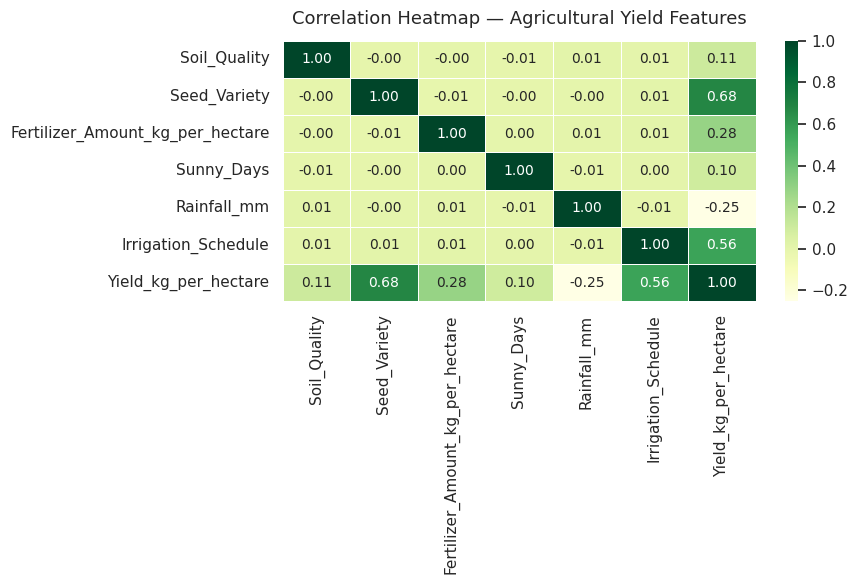


Interpretation:
- Soil_Quality and Fertilizer_Amount show the strongest positive correlations with Yield.
- Rainfall_mm and Sunny_Days also contribute positively.
- Irrigation_Schedule has a moderate effect, suggesting frequency matters.
- Seed_Variety (binary) has a smaller but notable correlation — all features will be kept.



In [12]:
# --- Visualization 1: Correlation Heatmap ---
# Shows which features have the strongest linear relationship with yield
plt.figure(figsize=(9, 6))
corr = train_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Heatmap — Agricultural Yield Features', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("""
Interpretation:
- Soil_Quality and Fertilizer_Amount show the strongest positive correlations with Yield.
- Rainfall_mm and Sunny_Days also contribute positively.
- Irrigation_Schedule has a moderate effect, suggesting frequency matters.
- Seed_Variety (binary) has a smaller but notable correlation — all features will be kept.
""")

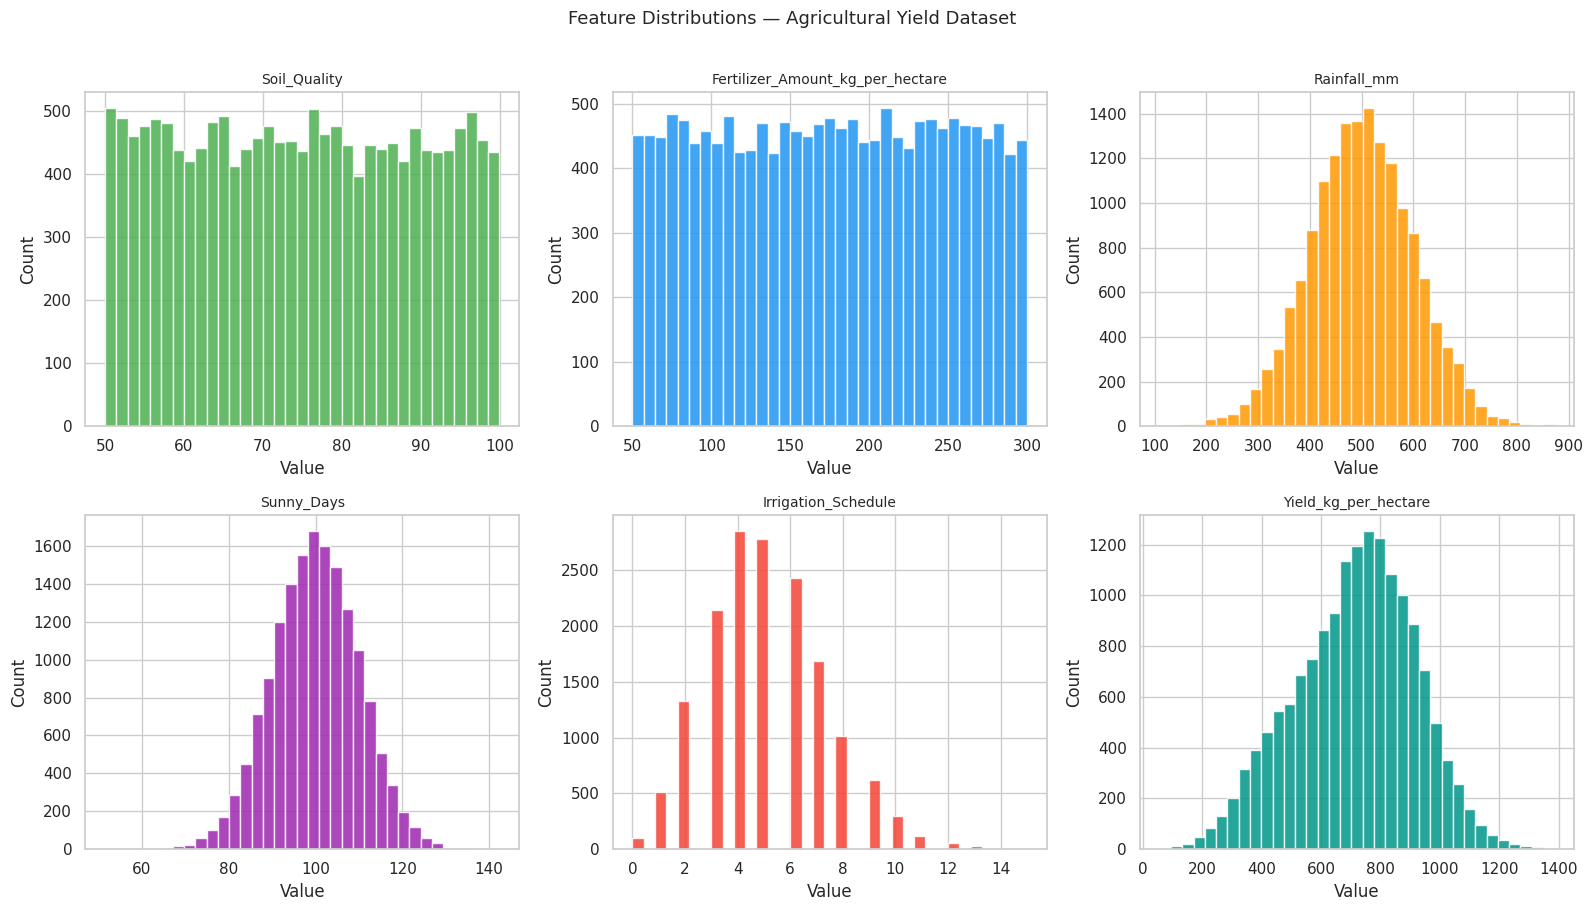


Interpretation:
- Soil_Quality is roughly uniform (50-100) — no transformation needed.
- Fertilizer and Rainfall are approximately normally distributed — good for regression.
- Yield is normally distributed around ~714 kg/ha — ideal regression target.
- Irrigation_Schedule ranges 0-15 (ordinal integer) — kept as numeric.
- Seed_Variety is binary (0 or 1) — already numeric, no encoding needed.



In [13]:
# --- Visualization 2: Feature Distributions ---
# Histograms reveal skewness, outliers and scale differences across features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['Soil_Quality', 'Fertilizer_Amount_kg_per_hectare',
            'Rainfall_mm', 'Sunny_Days', 'Irrigation_Schedule', 'Yield_kg_per_hectare']
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336', '#009688']

for ax, feat, color in zip(axes.flatten(), features, colors):
    ax.hist(train_df[feat], bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions — Agricultural Yield Dataset', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

print("""
Interpretation:
- Soil_Quality is roughly uniform (50-100) — no transformation needed.
- Fertilizer and Rainfall are approximately normally distributed — good for regression.
- Yield is normally distributed around ~714 kg/ha — ideal regression target.
- Irrigation_Schedule ranges 0-15 (ordinal integer) — kept as numeric.
- Seed_Variety is binary (0 or 1) — already numeric, no encoding needed.
""")

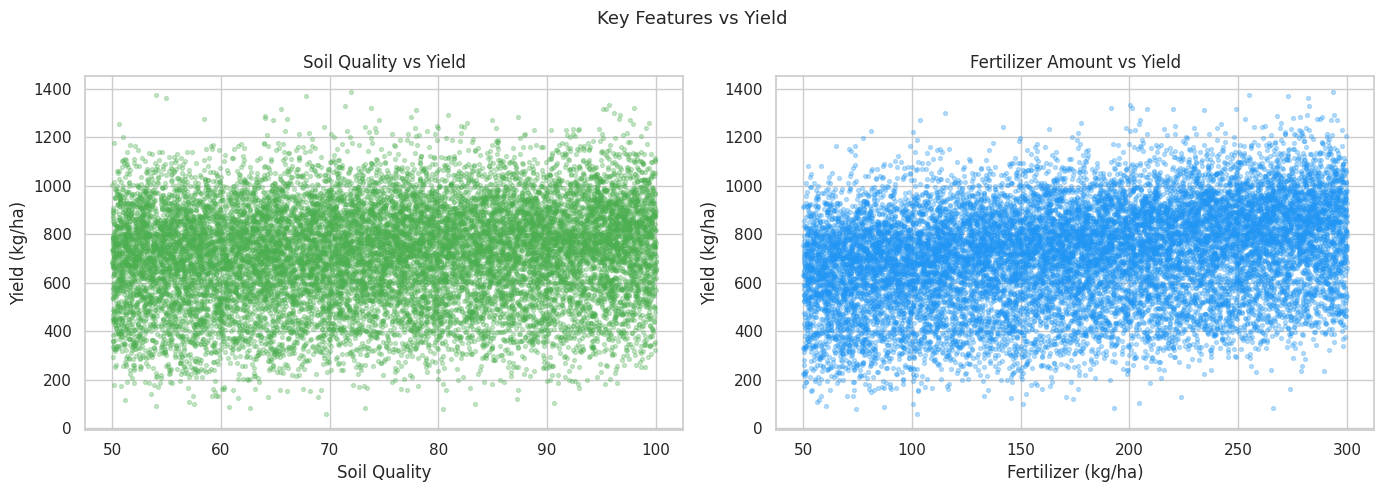

In [14]:
# --- Visualization 3: Top 2 Feature Scatterplots vs Yield ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_df['Soil_Quality'], train_df['Yield_kg_per_hectare'],
                alpha=0.3, color='#4CAF50', s=8)
axes[0].set_title('Soil Quality vs Yield')
axes[0].set_xlabel('Soil Quality')
axes[0].set_ylabel('Yield (kg/ha)')

axes[1].scatter(train_df['Fertilizer_Amount_kg_per_hectare'], train_df['Yield_kg_per_hectare'],
                alpha=0.3, color='#2196F3', s=8)
axes[1].set_title('Fertilizer Amount vs Yield')
axes[1].set_xlabel('Fertilizer (kg/ha)')
axes[1].set_ylabel('Yield (kg/ha)')

plt.suptitle('Key Features vs Yield', fontsize=13)
plt.tight_layout()
plt.savefig('scatter_features_vs_yield.png', dpi=150)
plt.show()

In [15]:
FEATURES = ['Soil_Quality', 'Seed_Variety', 'Fertilizer_Amount_kg_per_hectare',
            'Sunny_Days', 'Rainfall_mm', 'Irrigation_Schedule']
TARGET   = 'Yield_kg_per_hectare'

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

# Fit scaler on train only, apply to both (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Standardization complete.')
print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Standardization complete.
Train: (16000, 6) | Test: (4000, 6)


In [16]:
train_losses = []
test_losses  = []

# SGDRegressor with warm_start allows us to track loss per epoch manually
sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                   eta0=0.01, learning_rate='constant')

for epoch in range(1, 201):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,   sgd.predict(X_test_scaled)))

lr_test_pred  = sgd.predict(X_test_scaled)
lr_train_pred = sgd.predict(X_train_scaled)
lr_test_mse   = mean_squared_error(y_test, lr_test_pred)
lr_r2         = r2_score(y_test, lr_test_pred)

print(f'Linear Regression (SGD) — Test MSE: {lr_test_mse:,.2f} | R²: {lr_r2:.4f}')

Linear Regression (SGD) — Test MSE: 2,595.48 | R²: 0.9348


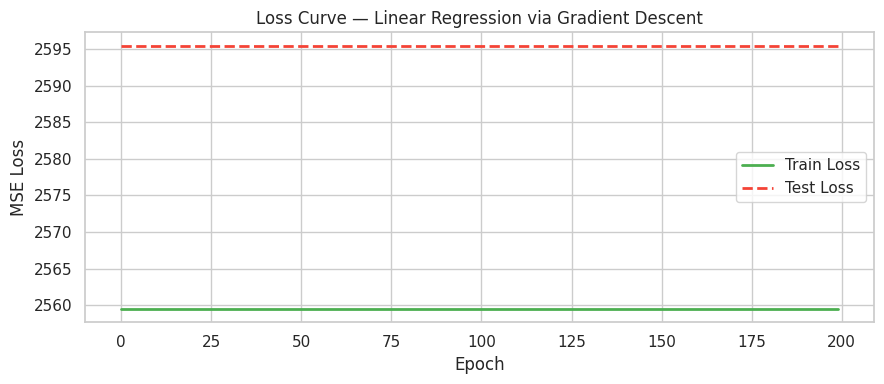

In [17]:
# Loss Curve — shows convergence of gradient descent over epochs
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='#4CAF50', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  color='#F44336', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve — Linear Regression via Gradient Descent')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

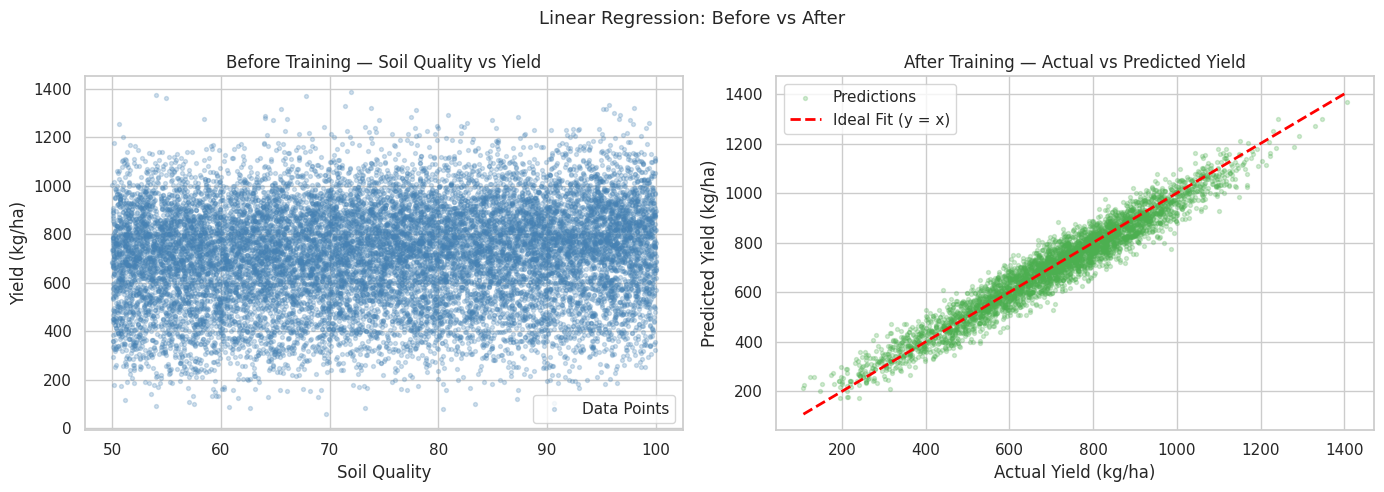

In [18]:
# Scatter Plot: Before training (raw data cloud) vs After training (predictions vs actuals)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: raw feature vs target with no model line
axes[0].scatter(train_df['Soil_Quality'], train_df['Yield_kg_per_hectare'],
                alpha=0.25, color='steelblue', s=8, label='Data Points')
axes[0].set_title('Before Training — Soil Quality vs Yield')
axes[0].set_xlabel('Soil Quality')
axes[0].set_ylabel('Yield (kg/ha)')
axes[0].legend()

# After: predicted vs actual with ideal fit line
axes[1].scatter(y_test, lr_test_pred, alpha=0.25, color='#4CAF50', s=8, label='Predictions')
lims = [min(y_test.min(), lr_test_pred.min()), max(y_test.max(), lr_test_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Ideal Fit (y = x)')
axes[1].set_title('After Training — Actual vs Predicted Yield')
axes[1].set_xlabel('Actual Yield (kg/ha)')
axes[1].set_ylabel('Predicted Yield (kg/ha)')
axes[1].legend()

plt.suptitle('Linear Regression: Before vs After', fontsize=13)
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150)
plt.show()

In [19]:
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)

dt_test_pred = dt.predict(X_test_scaled)
dt_test_mse  = mean_squared_error(y_test, dt_test_pred)
dt_r2        = r2_score(y_test, dt_test_pred)

print(f'Decision Tree — Test MSE: {dt_test_mse:,.2f} | R²: {dt_r2:.4f}')

Decision Tree — Test MSE: 4,569.62 | R²: 0.8852


In [20]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_test_pred = rf.predict(X_test_scaled)
rf_test_mse  = mean_squared_error(y_test, rf_test_pred)
rf_r2        = r2_score(y_test, rf_test_pred)

print(f'Random Forest — Test MSE: {rf_test_mse:,.2f} | R²: {rf_r2:.4f}')

Random Forest — Test MSE: 2,994.15 | R²: 0.9247


In [21]:
results = pd.DataFrame({
    'Model':     ['Linear Regression (SGD)', 'Decision Tree', 'Random Forest'],
    'Test MSE':  [lr_test_mse, dt_test_mse, rf_test_mse],
    'Test RMSE': [np.sqrt(lr_test_mse), np.sqrt(dt_test_mse), np.sqrt(rf_test_mse)],
    'R² Score':  [lr_r2, dt_r2, rf_r2]
}).sort_values('Test MSE').reset_index(drop=True)

print(results.to_string(index=False))
best_model_name = results.iloc[0]['Model']
print(f'\n Best Model: {best_model_name}')

                  Model    Test MSE  Test RMSE  R² Score
Linear Regression (SGD) 2595.476913  50.945823  0.934770
          Random Forest 2994.154025  54.718864  0.924750
          Decision Tree 4569.622995  67.598987  0.885155

 Best Model: Linear Regression (SGD)


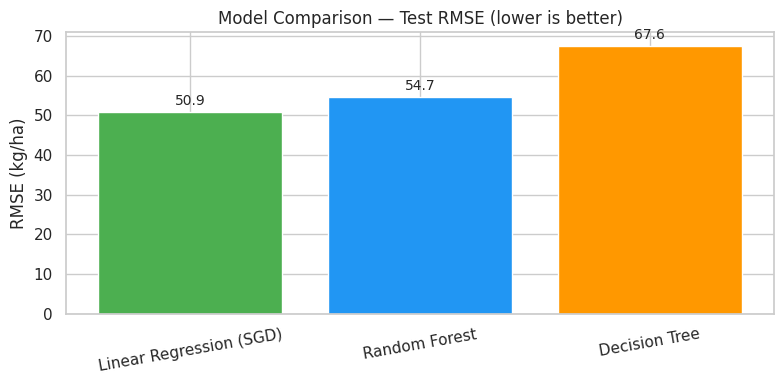

In [22]:
# Bar chart — model RMSE comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(results['Model'], results['Test RMSE'],
               color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='white')
plt.title('Model Comparison — Test RMSE (lower is better)')
plt.ylabel('RMSE (kg/ha)')
plt.xticks(rotation=10)
for bar, val in zip(bars, results['Test RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [23]:
# Save the best-performing model and scaler for use in the API
model_map = {
    'Linear Regression (SGD)': sgd,
    'Decision Tree':           dt,
    'Random Forest':           rf
}
best_model = model_map[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f'Saved: best_model.pkl ({best_model_name}) and scaler.pkl')

Saved: best_model.pkl (Linear Regression (SGD)) and scaler.pkl


In [24]:
def predict_yield(
    soil_quality: float,
    seed_variety: int,
    fertilizer_kg_per_ha: float,
    sunny_days: float,
    rainfall_mm: float,
    irrigation_schedule: int
) -> float:
    """
    Predict crop yield (kg/hectare) given farming inputs.

    Parameters
    ----------
    soil_quality         : float  — soil quality score (50–100)
    seed_variety         : int    — seed type: 0 = traditional, 1 = improved
    fertilizer_kg_per_ha : float  — fertilizer applied in kg/hectare
    sunny_days           : float  — number of sunny days in growing season
    rainfall_mm          : float  — total rainfall in mm
    irrigation_schedule  : int    — irrigation frequency score (0–15)

    Returns
    -------
    float — predicted yield in kg/hectare
    """
    model  = joblib.load('best_model.pkl')
    scaler = joblib.load('scaler.pkl')

    features = np.array([[soil_quality, seed_variety, fertilizer_kg_per_ha,
                          sunny_days, rainfall_mm, irrigation_schedule]])
    features_scaled = scaler.transform(features)
    return round(float(model.predict(features_scaled)[0]), 2)


# --- Test on one row from the test set ---
sample  = X_test.iloc[0]
actual  = y_test.iloc[0]

predicted = predict_yield(
    soil_quality          = sample['Soil_Quality'],
    seed_variety          = int(sample['Seed_Variety']),
    fertilizer_kg_per_ha  = sample['Fertilizer_Amount_kg_per_hectare'],
    sunny_days            = sample['Sunny_Days'],
    rainfall_mm           = sample['Rainfall_mm'],
    irrigation_schedule   = int(sample['Irrigation_Schedule'])
)

print(f'Input: {sample.to_dict()}')
print(f'\nActual Yield:    {actual:.2f} kg/ha')
print(f'Predicted Yield: {predicted:.2f} kg/ha')

Input: {'Soil_Quality': 93.3047207622014, 'Seed_Variety': 0.0, 'Fertilizer_Amount_kg_per_hectare': 132.5222176089096, 'Sunny_Days': 96.67092180524013, 'Rainfall_mm': 602.3862371830157, 'Irrigation_Schedule': 3.0}

Actual Yield:    278.99 kg/ha
Predicted Yield: 334.83 kg/ha
